# <span style="color:#185FA5">Loan Approval Prediction</span>

In this project I trained and evaluated 4 classification models — Logistic Regression, KNN, Naive Bayes and Decision Tree — on a dataset of 2000 loan applicants.
I found the best prediction model by evaluating Accuracy score, F1, ROC_AUC average metrics after 10-fold cross-validating each model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

In [2]:
data = pd.read_csv(r"C:\Users\User\Downloads\loan_approval.csv")
data

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False
...,...,...,...,...,...,...,...,...
1995,James Schaefer,Robertton,92163,770,12251,13,85.0,True
1996,Diana Lin,New Frank,38799,635,48259,17,40.0,False
1997,Brandon Meyer,East Haley,41957,763,16752,5,60.0,True
1998,Jason Price,Adamland,139022,360,24031,35,55.0,False


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   str    
 1   city            2000 non-null   str    
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), str(2)
memory usage: 111.5 KB


In [4]:
data.describe()

,income,credit_score,loan_amount,years_employed,points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,573.946000,25308.503000,20.441000,56.680000
std,34487.874907,160.564945,14207.320147,11.777813,18.638033
min,30053.000000,300.000000,1022.000000,0.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,715.000000,37380.500000,31.000000,70.000000
max,149964.000000,850.000000,49999.000000,40.000000,100.000000


In [5]:
data.drop('name',axis=1,inplace=True)

In [6]:
v = data.city.value_counts()
values, counts = np.unique(v.values, return_counts=True)
print(values,counts)
print(v)

[1 2 3 4] [1776   95   10    1]
city
North Joseph        4
North Michael       3
Port Michael        3
Christinachester    3
West Melissa        3
                   ..
Robertton           1
New Frank           1
East Haley          1
Adamland            1
New Nathantown      1
Name: count, Length: 1882, dtype: int64


In [7]:
data.drop('city',axis=1,inplace=True)

In [8]:
data.loan_approved = data.loan_approved.astype('int8')
data

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389,39698,27,50.0,0
1,44592,729,15446,28,55.0,0
2,33278,584,11189,13,45.0,0
3,127196,344,48823,29,50.0,0
4,66048,496,47174,4,25.0,0
...,...,...,...,...,...,...
1995,92163,770,12251,13,85.0,1
1996,38799,635,48259,17,40.0,0
1997,41957,763,16752,5,60.0,1
1998,139022,360,24031,35,55.0,0


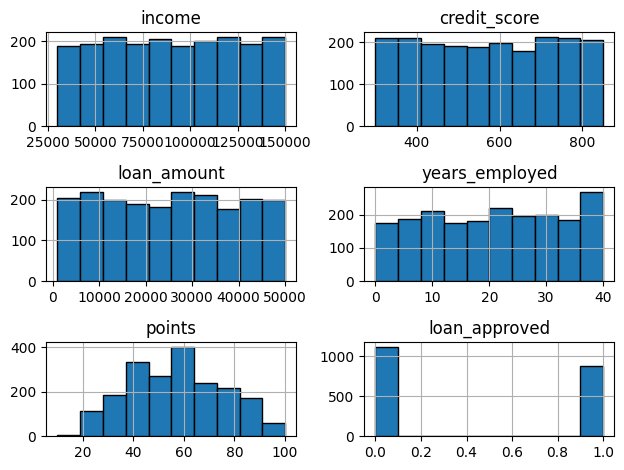

In [9]:
data.hist(edgecolor = 'black')
plt.tight_layout()

In [10]:
data.loan_approved.value_counts()

loan_approved
0    1121
1     879
Name: count, dtype: int64

<Axes: >

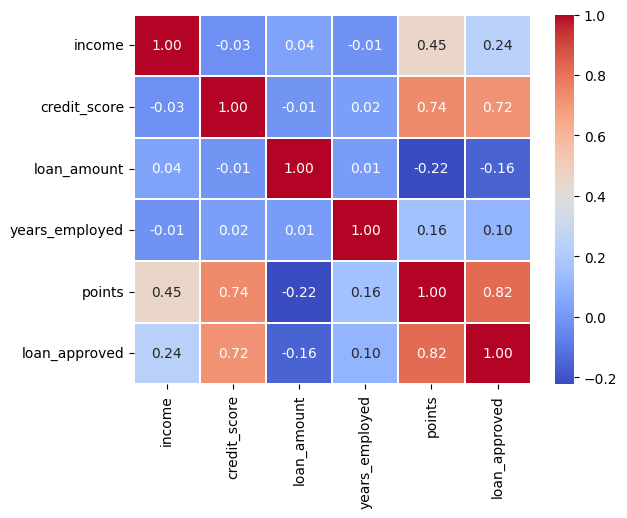

In [11]:
plt.figsize = (8,7)
sns.heatmap(data.corr(), annot = True, fmt = ".2f", cmap = 'coolwarm', linewidth = 0.1)

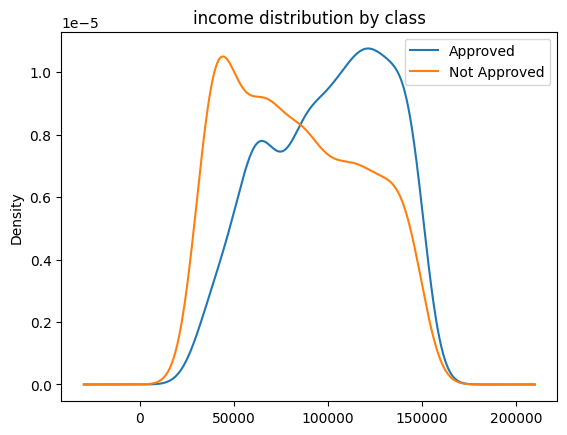

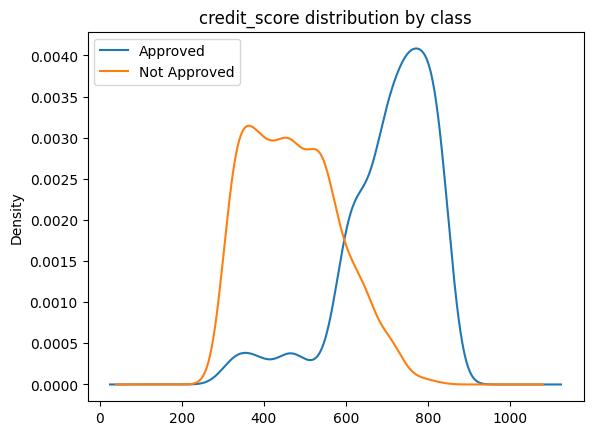

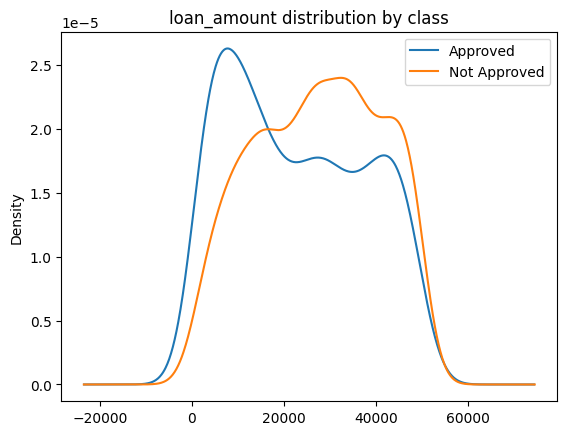

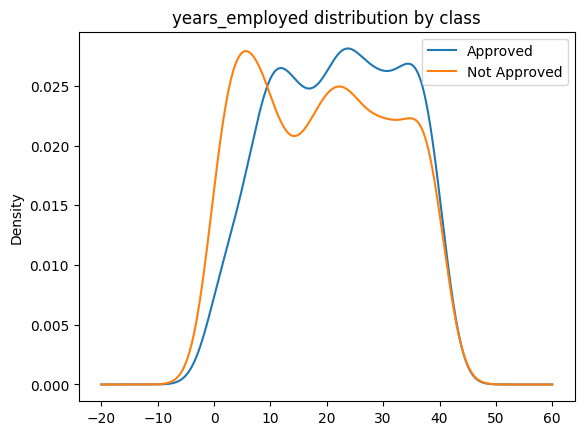

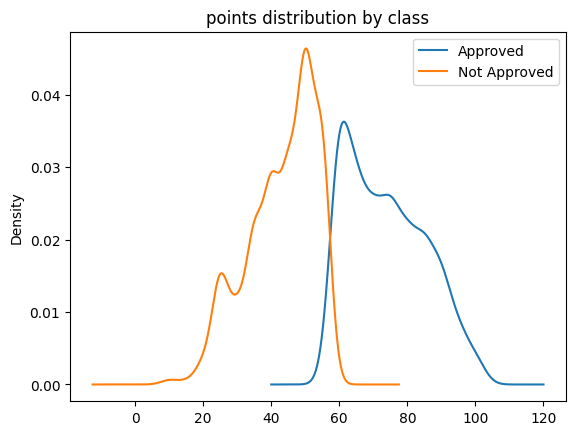

In [12]:
cols = data.drop('loan_approved',axis=1).columns
for c in cols:
    plt.figure()
    data[data.loan_approved == 1][c].plot(kind = 'kde', label = 'Approved')
    data[data.loan_approved == 0][c].plot(kind = 'kde', label = 'Not Approved')
    plt.title(f"{c} distribution by class")
    plt.legend()
    

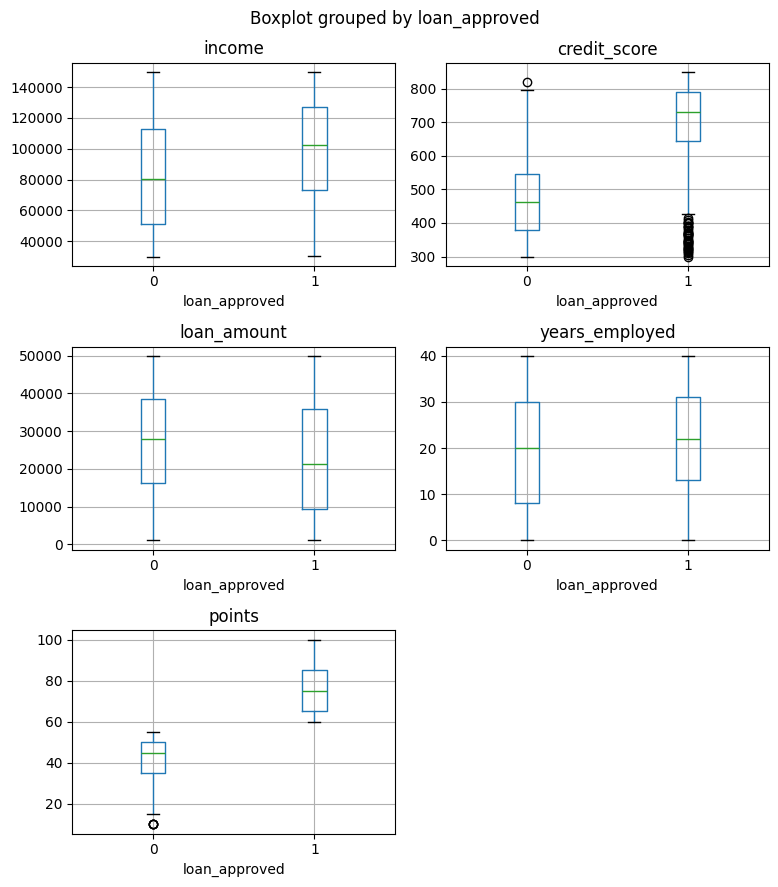

In [13]:
import math
fig, ax = plt.subplots(math.ceil(len(cols)/2),2,figsize = (8,9))
ax = ax.flatten()
for i,c in enumerate(cols):
    data.boxplot(column = c, by = 'loan_approved', ax = ax[i])
plt.tight_layout()
for i in range(len(cols), len(ax)):
    plt.delaxes(ax[i])

## EDA:
1. Removed 'name', 'city' columns, as customer's name cannot be a metric for a loan approval or disapproval. Out of 2000 customers 1776 were coming from different cities, only 1 city appeared 4 times, so 'city' customer is not an accurate metric.
2. Data is balanced with 1121 not approved and 879 approved loans.
3. Credit Score and Points had the most impact on loan approval (positive correlations of ~0.72, ~0.82).
4. KDE plots show that higher credit scores and higher points most likely get approval.
5. Boxplots show there's no skewing outliers in data.

In [14]:
data.drop('points',axis=1,inplace=True)

In [15]:
x = data.drop('loan_approved', axis = 1).values
y = data.loan_approved.values

In [16]:
#Logistic Regression
lr = LogisticRegression()

In [17]:
cv = KFold(n_splits=10, shuffle = True, random_state=0)
f1, roc_auc, acc = [],[],[]
for tr_idx, te_idx in cv.split(x):
    x_train, y_train = x[tr_idx], y[tr_idx]
    x_test, y_test = x[te_idx], y[te_idx]
    sc = StandardScaler()
    x_train_sc = sc.fit_transform(x_train)
    x_test_sc = sc.transform(x_test)
    lr.fit(x_train_sc, y_train)
    y_pr = lr.predict(x_test_sc)
    y_prob = lr.predict_proba(x_test_sc)[:,1]
    acc.append(accuracy_score(y_test, y_pr))
    f1.append(f1_score(y_test, y_pr))
    roc_auc.append(roc_auc_score(y_test, y_prob))
    

In [18]:
print(f"Accuracy: {np.mean(acc):.4f}")
print(f"F1: {np.mean(f1):.4f}")
print(f"Roc_auc: {np.mean(roc_auc):.4f}")


Accuracy: 0.9065
F1: 0.8942
Roc_auc: 0.9679


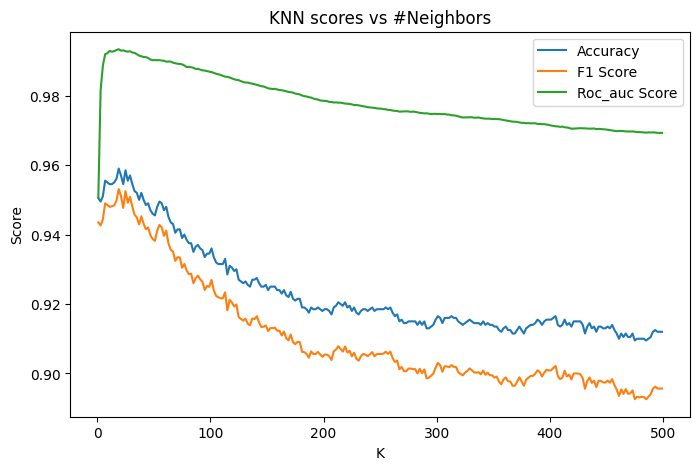

In [19]:
#knn
k_range = range(1,500,2)
f1_,acc_,roc_auc_=[],[],[]
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv = KFold(n_splits=10, shuffle = True, random_state=0)
    f1k, roc_auck, acck = [],[],[]
    for tr_idx, te_idx in cv.split(x):
        x_train, y_train = x[tr_idx], y[tr_idx]
        x_test, y_test = x[te_idx], y[te_idx]
        sc = StandardScaler()
        x_train_sc = sc.fit_transform(x_train)
        x_test_sc = sc.transform(x_test)
        knn.fit(x_train_sc, y_train)
        y_pr = knn.predict(x_test_sc)
        y_prob = knn.predict_proba(x_test_sc)[:,1]
        acck.append(accuracy_score(y_test, y_pr))
        f1k.append(f1_score(y_test, y_pr))
        roc_auck.append(roc_auc_score(y_test, y_prob))
    f1_.append(np.mean(f1k))
    roc_auc_.append(np.mean(roc_auck))
    acc_.append(np.mean(acck))

plt.figure(figsize=(8, 5))
plt.plot(k_range, acc_, label='Accuracy')
plt.plot(k_range, f1_, label='F1 Score')
plt.plot(k_range, roc_auc_, label='Roc_auc Score')
plt.xlabel("K")
plt.ylabel("Score")
plt.title('KNN scores vs #Neighbors')
plt.legend()

In [20]:
print(f"Best K by Accuracy: {list(k_range)[np.argmax(acc_)]}, score={max(acc_):.4f}")
print(f"Best K by F1:       {list(k_range)[np.argmax(f1_)]}, score={max(f1_):.4f}")
print(f"Best K by ROC-AUC:  {list(k_range)[np.argmax(roc_auc_)]}, score={max(roc_auc_):.4f}")

Best K by Accuracy: 19, score=0.9590
Best K by F1:       19, score=0.9531
Best K by ROC-AUC:  19, score=0.9934


In [27]:
# Naive Bayes
gnb = GaussianNB()
cv = KFold(n_splits=10, shuffle = True, random_state=0)
f1nb, roc_aucnb, accnb = [],[],[]
for tr_idx, te_idx in cv.split(x):
    x_train, y_train = x[tr_idx], y[tr_idx]
    x_test, y_test = x[te_idx], y[te_idx]
    sc = StandardScaler()
    x_train_sc = sc.fit_transform(x_train)
    x_test_sc = sc.transform(x_test)
    gnb.fit(x_train_sc, y_train)
    y_pr = gnb.predict(x_test_sc)
    y_prob = gnb.predict_proba(x_test_sc)[:,1]
    accnb.append(accuracy_score(y_test, y_pr))
    f1nb.append(f1_score(y_test, y_pr))
    roc_aucnb.append(roc_auc_score(y_test, y_prob))
print(f"Accuracy: {np.mean(accnb)}")
print(f"F1: {np.mean(f1nb):.4f}")
print(f"Roc_auc: {np.mean(roc_aucnb):.4f}")

Accuracy: 0.9065
F1: 0.8934
Roc_auc: 0.9515


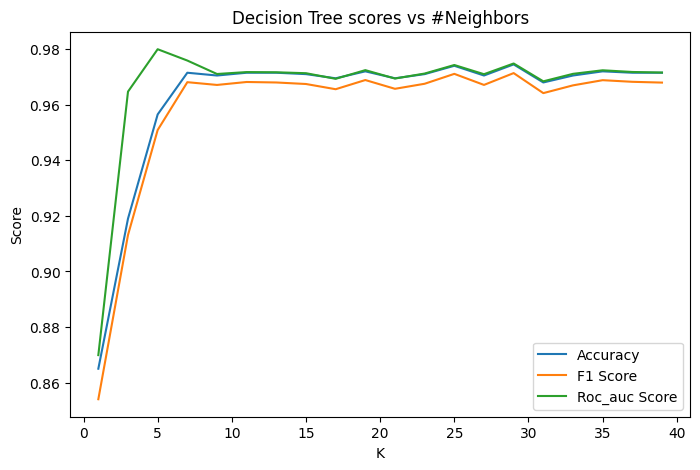

In [22]:
depth_range = range(1,40,2)
f1dt,accdt,roc_aucdt=[],[],[]
for d in depth_range:
    dt = DecisionTreeClassifier(max_depth=d)
    cv = KFold(n_splits=10, shuffle = True, random_state=0)
    f1k, roc_auck, acck = [],[],[]
    for tr_idx, te_idx in cv.split(x):
        x_train, y_train = x[tr_idx], y[tr_idx]
        x_test, y_test = x[te_idx], y[te_idx]
        sc = StandardScaler()
        x_train_sc = sc.fit_transform(x_train)
        x_test_sc = sc.transform(x_test)
        dt.fit(x_train_sc, y_train)
        y_pr = dt.predict(x_test_sc)
        y_prob = dt.predict_proba(x_test_sc)[:,1]
        acck.append(accuracy_score(y_test, y_pr))
        f1k.append(f1_score(y_test, y_pr))
        roc_auck.append(roc_auc_score(y_test, y_prob))
    f1dt.append(np.mean(f1k))
    roc_aucdt.append(np.mean(roc_auck))
    accdt.append(np.mean(acck))

plt.figure(figsize=(8, 5))
plt.plot(depth_range, accdt, label='Accuracy')
plt.plot(depth_range, f1dt, label='F1 Score')
plt.plot(depth_range, roc_aucdt, label='Roc_auc Score')
plt.xlabel("K")
plt.ylabel("Score")
plt.title('Decision Tree scores vs #Neighbors')
plt.legend()

In [23]:
print(f"Best K by Accuracy: {list(depth_range)[np.argmax(accdt)]}, score={max(accdt):.4f}")
print(f"Best K by F1:       {list(depth_range)[np.argmax(f1dt)]}, score={max(f1dt):.4f}")
print(f"Best K by ROC-AUC:  {list(depth_range)[np.argmax(roc_aucdt)]}, score={max(roc_aucdt):.4f}")

Best K by Accuracy: 29, score=0.9745
Best K by F1:       29, score=0.9714
Best K by ROC-AUC:  5, score=0.9800


In [24]:
dt = DecisionTreeClassifier(max_depth=21)
cv = KFold(n_splits=10, shuffle = True, random_state=0)
f1k, roc_auck, acck = [],[],[]
for tr_idx, te_idx in cv.split(x):
    x_train, y_train = x[tr_idx], y[tr_idx]
    x_test, y_test = x[te_idx], y[te_idx]
    sc = StandardScaler()
    x_train_sc = sc.fit_transform(x_train)
    x_test_sc = sc.transform(x_test)
    dt.fit(x_train_sc, y_train)
    y_pr = dt.predict(x_test_sc)
    y_prob = dt.predict_proba(x_test_sc)[:,1]
    acck.append(accuracy_score(y_test, y_pr))
    f1k.append(f1_score(y_test, y_pr))
    roc_auck.append(roc_auc_score(y_test, y_prob))
print(np.mean(f1k))
print(np.mean(acck))
np.mean(roc_auck)

0.9656783666680718
0.9694999999999998


np.float64(0.9695494440617803)

## Wrap up

In [28]:
d = {"Logistic Regression": [0.9065, 0.8942, 0.9679], 
     "KNN": [0.9590,0.9531,0.9934], 
     "Naive Bayes": [0.9065,0.8934,0.9515], 
     "Decision Tree": [0.9672, 0.9705,0.9707]}

In [29]:
pd.DataFrame(d, index = ['Accuracy','F1','Roc_Auc'])

,Logistic Regression,KNN,Naive Bayes,Decision Tree
Accuracy,0.9065,0.9590,0.9065,0.9672
F1,0.8942,0.9531,0.8934,0.9705
Roc_Auc,0.9679,0.9934,0.9515,0.9707


For Decision Tree I chose max depth of 21 to get the final scores, I chose to prioritize F1 score.

<u>Highest accuracy -> Decision Tree = 0.9672</u>

<u>Highest F1 -> Desicion Tree = 0.9705</u>

<u>Highest Roc_auc -> KNN = 0.9934</u>

The winner is <u>Decision Tree</u> for this dataset with accuracy of prediction of unseen testing data 97%.